# Transformer 챗봇 만들기 (NLP02)

한국어 질문-답변 데이터(songys/Chatbot_data, 약 1.1만 쌍)로 Transformer 챗봇을 만드는 프로젝트다.  

루브릭은 세 가지다.  

1. 전처리와 augmentation으로 3만 개가량의 훈련 데이터셋을 구축한다  
2. 과적합을 피할 수 있는 하이퍼파라미터 셋을 제시한다  
3. 주어진 예문을 포함해서 질문에 적절히 답하는 사례를 제출한다  

노드에서 준 코드를 그대로 돌려서 내는 대신, 코드를 직접 뜯어보면서 진행하기로 했다.  
그 과정에서 노드 코드의 문제점 몇 개를 찾았고(퍼실님이 잡아준 것 + 내가 찾은 것),  
왜 문제인지 실험으로 확인한 뒤 고쳐서 쓴다. 그 과정을 이 노트북에 순서대로 적는다.  

같은 Transformer 구현을 NLP03(번역기)에서도 쓸 거라서, 두 프로젝트에서 공용으로  
쓸 수 있게 만들었다.


## 1. 구현을 시작하기 전에 — 남의 구현 네 개를 나란히 읽었다

퍼실님이 노드 코드에서 버그(스택 끝 LayerNorm 누락)를 잡아줬다. 하나가 있으면 더 있을 수 있겠다 싶어서,  
코드를 그대로 믿지 않고 다른 구현들과 대조부터 했다.  

대조 대상은 네 개다.  

1. 아이펠 노드 학습 중 - 파이토치 코드 (베이스 후보)  
2. jaygala24 의 파이토치 구현 노트북  
3. 하버드 Annotated Transformer  
4. cpm0722 블로그 (아이펠이 노드용 노션에 참조로 걸어준 글) - 진짜 코드는 깃허브 cpm0722/transformer_pytorch  

핵심만 표로 정리하면 이렇다.  

| | 아이펠 (노드) | jaygala24 | 하버드 | cpm0722 (깃허브) |
|---|---|---|---|---|
| LN 위치 | Pre-LN | Post-LN | Pre-LN | Pre-LN |
| 스택 끝 final LayerNorm | 없음 (버그) | 있음 | 있음 | 있음 |
| 마스크 규약 | 1 = 가린다 | 1 = 살린다 | 1 = 살린다 | 1 = 살린다 |
| 패딩 토큰 인덱스 | 0 | 1 | 0 | 1 |
| 어텐션 확률에 dropout | 안 함 | 함 | 함 | 함 |
| attention 반환 | 전 레이어 다 | 마지막 레이어만 | 안 함 | 안 함 (버림) |

읽으면서 알게 된 것들:

- Pre-LN을 쓴 세 구현 중에 스택 끝 정규화가 없는 건 아이펠 코드뿐이다. 심지어 아이펠이  
  참조로 걸어준 cpm0722 코드에도 있다. 정규화 누락이 실수라는 증거가 셋이 됐다.  
- cpm0722는 블로그 본문 코드가 LayerNorm과 Dropout을 일부러 생략한 버전이라고 저자가  
  직접 밝혀놨다. 블로그만 보고 따라 치면 정규화가 통째로 빠진 모델이 나온다.  
- jaygala24 코드에는 버그가 두 개 있었다. 디코더에서 LayerNorm 하나를 두 자리에  
  재사용하는 것, 그리고 Positional Encoding을 `self.pe[:x.size(0)]` 로 잘라서 위치가  
  아니라 배치 번호에 PE를 붙이는 것. star 수와 정확성은 무관하다는 걸 배웠다.  
- 마스크 규약이 아이펠만 반대다(1 = 가린다). 남의 코드를 그대로 섞으면 에러 없이  
  정반대로 동작한다. 패딩만 보고 진짜 단어를 다 가리게 된다.  

ㅁ 결정: 베이스는 아이펠 제공 코드로 한다.  
   . 마스크 규약과 `generate_masks()`, 그리고 모든 레이어의 어텐션을 리스트로 모아 반환하는 인터페이스가 프로젝트 채점(NLP03의 Attention Map 시각화 포함)에 맞아서다.  
ㅁ 거기에 빠진 부품만 근거를 확인하고 가져와 붙인다:  
   . final_norm(하버드, cpm0722), 어텐션 확률 dropout(셋 다 있음), Noam 스케줄러의 factor(하버드), padding_idx(jaygala24).  

한 가지 정직하게 밝혀둔다. 이 네 구현을 처음부터 끝까지 통독한 건 아니다.  
우리 코드와 어긋나는 지점을 중심으로 필요한 부분만 찾아 대조했고, 영어로 된 글은 검색과 번역기를 써가며 읽었다.  
논문(Attention is All You Need)도 마찬가지다. 원문을 열어 몇 문단은 직접 읽었지만  
대부분은 요약 도구(NotebookLM)로 공부하고 필요한 절을 찾아보는 식이었다.  
아래에서 "논문 5.3절 / 5.4절"을 근거로 대는 대목은 그렇게 확인한 것이지,  
논문을 통째로 소화하고 쓴 것은 아니다.  


## 2. final_norm이 왜 필요한지 직접 재봤다

퍼실님 설명은 "Pre-LN에서 residual이 계속 누적되어 값이 폭주하고, 그게 cross-attention의  
K, V로 들어가 softmax가 한 자리에 몰린다(모드 붕괴)"였다.   
결론(스택 끝에 LayerNorm 추가)이 맞는지, 그리고 원인 설명이 맞는지 작은 스크립트로 직접 재봤다.  
d_model=512, 2층, 학습 전 랜덤 초기화 기준이다.  

```
                    final_norm 없음   있음  
임베딩 직후 std        22.637          22.637  
1번 레이어 후 std      22.639          22.639  
2번 레이어 후 std      22.642          22.642  
final_norm 후 std        -           1.000  
어텐션 logit std       13.13           0.58  
최대 확률(평균)        0.8949          0.1288  
엔트로피(균등=3.00)    0.2570          2.8409  
```

재보고 알게 된 것:  

- residual 누적은 거의 없다. 22.637에서 22.642로 늘 뿐이다. 큰 값에 작은 값을 더하면  
  sqrt(22.637^2 + 1^2) = 22.659 라서 티가 안 난다.  
- 진범은 임베딩에 곱하는 sqrt(d_model) = sqrt(512) = 22.627 이다. 이걸 곱해놓고 Pre-LN은  
  residual 본선을 한 번도 정규화하지 않으니, 22.6배가 스택 끝까지 그대로 살아 나간다.  
- 어텐션 logit std의 비율이 13.13 / 0.58 = 22.6 으로 정확히 그 배수다.  
- 그 결과 softmax가 한 자리에 89%를 몰아주고(엔트로피 0.26), final_norm을 붙이면  
  13%로 퍼진다(엔트로피 2.84, 균등이 3.00).  

그러니까 결론은 퍼실님 말대로 final_norm 추가가 맞는데, 원인은 residual 누적이 아니라  
임베딩 스케일링이 안 지워지는 것이었다. 단, 이 실험은 2층에 학습 전 기준이라서, 층이  
깊어지거나 학습이 진행되면 residual 누적도 유의미해질 수 있다.  

참고로,  
- 로짓(Logit)은 머신러닝과 통계학에서 활성화 함수(시그모이드, 소프트맥스)를  
  거치기 전 모델의 최종 원시 출력값(Raw score)을 의미한다고 한다.
- 엔트로피는 확률이 얼마나 퍼져 있냐를 재는 숫자라고 한다.  
  . 한 곳에 100% 몰빵: [1, 0, 0, ...] -> 엔트로피 0 (완전 집중)  
  . 20군데 균등하게 5%씩: [0.05 x 20] -> 엔트로피 ln(20) = 3.00 (완전 분산)  
- BOS/EOS는 Begin/End of Sentence.  
- 모드 붕괴(Mode Collapse)는 주로 생성형 AI(예: GAN, LLM)에서 발생하는 현상으로,  
  모델이 훈련 데이터의 다양한 패턴을 무시하고 극히 제한적이거나 단조로운 결과물만 반복해서 생성하는 오류를 말한다고 한다.


## 3. 시작 전에 못박은 규약

구현들을 대조해보니 규약이 제각각이라, 섞으면 에러 없이 조용히 망가진다고 한다.  
그래서 먼저 하나로 못박았다.  

```
PAD = 0, BOS = 1, EOS = 2, UNK = 3      (NLP03 SentencePiece 지시문의 값으로 통일)
마스크 값 1 = 가린다                        (아이펠 코드 기준 규약. 나머지 셋은 1 = 살린다로 정반대)
마스킹 적용 = scaled_qk + (mask * -1e9)   (masked_fill(가릴 자리의 점수를 -1e9로 교체)가 아니라 
                                        덧셈(점수에 mask * -1e9를 더함))
마스킹 값 = -1e9                          (-inf는 전부 마스크된 행에서 softmax가 nan이 된다)
```

마스크 두 장(패딩 + 룩어헤드)을 겹칠 때는 `torch.max` 를 쓴다. 0/1 텐서에서 원소별 max는  
"하나라도 1이면 1", 즉 OR 연산이다. 1이 "가린다"라는 규약에서는 하나라도 가리자고 하면 가려야 하니까 OR가 맞다.  
하버드처럼 1이 "살린다"인 규약이면 반대로 AND(`&`)를 써야 한다.  
연산자까지 반대가 되는 것이다.  


덧셈이 되는 이유는 mask가 0/1이라서.  

숫자로 보면, 점수가 [2.1, 0.3, 1.5]이고 mask가 [0, 0, 1](셋째를 가려라)이면:

mask * -1e9        = [0, 0, -1000000000]
점수 + (mask*-1e9)  = [2.1, 0.3, -999999998.5]
softmax            = [0.86, 0.14, 0.0000...]   <- 셋째가 죽었다

mask=0인 자리는 0을 더하니 그대로고, mask=1인 자리만 점수가 -10억이 돼서 softmax에서 소멸함.  
결과는 masked_fill과 같은데, 이 방식은 mask가 "1=가린다" 규약일 때만 말이 되는 코드라서 대조표에 굳이 적어둠.  
(하버드처럼 1=살린다 규약이면 이 덧셈은 정반대로 동작해버림).


### 규약을 섞으면 정확히 어떻게 되나 — 손으로 따라가 봤다

"조용히 망가진다"고 하는게 어떤 것이지가 감이 안 와서, 규약이 반대인 마스크와 코드를 엇갈려 짝지으면  
무슨 일이 나는지 값을 넣고 추적해봤다. 문장이 `[진짜, 진짜, PAD]` 라고 하자.

하버드 마스크(1=살린다)를 우리 덧셈 코드에 꽂으면:

```
하버드 마스크:      [1, 1, 0]        <- 진짜 단어에 1(살려라)
mask * -1e9        = [-1e9, -1e9, 0]
점수 + (mask*-1e9) = [죽음, 죽음, 멀쩡]   <- 진짜 단어가 죽는다!
```

반대로 우리 마스크(1=가린다)를 하버드의 `masked_fill(mask == 0, -1e9)` 에 꽂으면:

```
우리 마스크:  [0, 0, 1]              <- 패딩에만 1(가려라)
mask == 0  -> [True, True, False]    <- "0인 자리"를 찾는다
masked_fill -> [죽음, 죽음, 멀쩡]      <- 이번에도 진짜 단어가 죽는다!
```

어느 방향으로 섞어도 죽는 쪽은 진짜 단어다. 코드는 마스크의 "의미"를 모르는 집행자라서  
(덧셈 코드는 "1인 자리를 죽여라", masked_fill(mask==0)은 "0인 자리를 죽여라"를 기계적으로  
실행할 뿐), 명단의 규약이 엇갈리는 순간 보호하려던 쪽에 집행이 떨어진다.  
모델은 몇 칸 안 되는 패딩만 쳐다보며 답을 지어내는데, 에러는 안 나고 loss도 내려간다.  

처음에 나는 "마스크란 패딩을 가리는 물건이니 패딩이 죽겠지"라고 감으로 추측했다가 틀렸다.  
교훈: 마스크 코드는 의미로 판단하지 말고, 작은 값을 하나 넣어서  
`mask == 0` 이 어디서 True가 되는지 한 줄씩 추적해서 검산한다.  


## 4. Transformer 구현

아이펠 노드 코드를 베이스로 하되, 위에서 확인한 문제 4가지를 고쳤다.

1. Encoder / Decoder 스택 끝에 final_norm 추가 (2절에서 실측한 그것)
2. 임베딩의 sqrt(d_model) 스케일링을 shared_fc 조건 밖으로 분리
3. 어텐션 확률에 dropout 추가 (논문 5.4절이 아니라 참조 구현 셋의 공통 관행. 루브릭 2번 과적합 방어와 직결)
4. generate_masks() 의 전역 device 의존 제거 (함수가 "바깥 사정"을 몰래 참조하면 안 되기 때문에)

각 수정 지점에 주석으로 근거를 같이 적어뒀다.


In [1]:
import math

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# 특수 토큰 인덱스. NLP03 SentencePiece 지시문 값으로 두 프로젝트 다 통일한다.
# cpm0722는 pad_idx=1 이라서 그대로 베끼면 <BOS>가 패딩 취급된다 -> 0으로 못박음.
PAD = 0
BOS = 1
EOS = 2
UNK = 3

### 4-1. Positional Encoding

Transformer는 RNN과 달리 순서를 볼 수단이 없어서, 위치마다 다른 sin/cos 파형 벡터를  
임베딩에 더해 순서 정보를 넣어준다. 노드 코드 그대로다.  

여담으로 jaygala24 구현은 이 표를 `self.pe[:x.size(0)]` 로 잘라 쓰는 바람에  
문장 내 위치가 아니라 배치 번호에 PE를 붙였다.  
그러면 문장 안에서 순서 정보가 통째로 사라져서 사실상 단어 가방이 된다.  
그러니까, 슬라이스 한 줄도 shape를 따라가 봐야 한다.


참고로 (파이썬 문법),
- 함수 안에 함수 2개(`cal_angle`, `get_posi_angle_vec`)가 있는 건 이 함수 전용 조수를 감춰두는 용도다.  
  안쪽 함수가 바깥의 `d_model` 을 물고 있으니 기술적으로는 클로저다.
- `sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])` 에서
  `pos_i` 의 출생지는 이 줄 자체다. `for pos_i in range(pos)` 가 0, 1, ..., pos-1 을
  만들어내고, 그게 `get_posi_angle_vec(pos_i)` 호출의 인자로 전달된다. 풀어 쓰면:

```
rows = []
for pos_i in range(pos):                      # pos=3 이면 pos_i = 0, 1, 2
    rows.append(get_posi_angle_vec(pos_i))    # pos_i 가 position 인자로 전달됨
sinusoid_table = np.array(rows)
```

바깥 루프가 "몇 번째 위치(행)", 안쪽 컴프리헨션이 "몇 번째 차원(열)"을 돌아서
[pos x d_model] 표가 채워진다.


In [2]:
def positional_encoding(pos, d_model):
    """sin/cos 위치 인코딩 표를 만든다. 반환 shape = [pos, d_model]"""

    # 위치 position, 차원 i 에서의 각도. 짝수/홀수 차원이 같은 주기를 쓰도록 i//2
    def cal_angle(position, i):
        return position / np.power(10000, (2 * (i // 2)) / np.float32(d_model))

    # 한 위치에 대해 d_model개 차원의 각도 벡터를 만든다
    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]
    # sinusoid는 사인(Sine) 또는 코사인(Cosine) 함수 형태의 주기적 파형(정현파)를 뜻한다.
    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    # 짝수 차원에는 sin, 홀수 차원에는 cos
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table
    # 참고: jaygala24는 이 표를 self.pe[:x.size(0)] 로 잘라서 "위치"가 아니라
    # "배치 번호"에 PE를 붙이는 버그가 있었다. 나는 아이펠 방식(seq_len으로 슬라이스)을 쓴다.

### 4-2. 마스크 생성

어텐션 마스크는 결국 [행, 열] = [보는 놈, 보이는 놈] 표다. `mask[i][j] = 1` 이면  
"i번째 토큰이 j번째 토큰을 보면 안 된다"는 뜻이다.  

가리는 이유는 두 가지고, 참조하는 정보가 다르다.  

- 룩어헤드(미래 차단): 행과 열을 둘 다 봐야 판정된다. 그래서 태생부터 [T, T] 표다.  
- 패딩: 열(보이는 놈)만의 문제다. "3번 자리가 PAD면 누가 보든 못 본다".  
  그래서 원재료가 한 줄 [1, T] 이고, 브로드캐스팅이 모든 행에 복사해준다.  

인코더에는 룩어헤드를 안 겹친다. 소스 문장은 추론 때도 처음부터 통째로 주어지니까  
미래를 가릴 이유가 없다. 그래서 인코더는 패딩 마스크 한 장만 쓴다.  
겹치는 건 디코더 self-attention 뿐이다.  

여기서 "겹친다"가 정확히 무슨 연산인지 풀어 쓴다. 마스크 두 장을 같은 자리끼리 비교해서  
**둘 중 하나라도 1(가려라)이면 1로 만드는 것**이다. 3절에서 못박은 대로 1이 "가린다"인 규약이니  
한 장이라도 가리자고 하면 가려야 하고, 그게 OR 이다. 코드로는 `torch.max(a, b)` 로 쓴다  
(0과 1만 있는 표에서 원소별 최대값은 "하나라도 1이면 1"과 같으니까).  
그러니까 마스크는 "패딩 OR 미래"가 된다.

문장이 `[나, 는, PAD]` 세 칸이라고 놓고 실제로 겹쳐보면 이렇다.  

```
  룩어헤드(미래 차단)        패딩(PAD 열 차단)         torch.max = 겹친 결과
  행=보는놈 / 열=보이는놈    (한 줄이 모든 행에 복사)

     나  는  P                  나  는  P                  나  는  P
 나   0   1   1             나   0   0   1             나   0   1   1
 는   0   0   1             는   0   0   1             는   0   0   1
 P    0   0   0             P    0   0   1             P    0   0   1
```

읽는 법은 이렇다. '나' 행의 두 번째 칸('는')을 보면 패딩 마스크는 0(통과)인데 룩어헤드가  
1(미래라 가려라)이다. 한 장만 가리자고 해도 결과는 가려진다. '는' 행의 세 번째 칸은  
미래이면서 동시에 PAD 라 두 장 다 1이고, 당연히 가려진다. 반대로 두 장 다 0인 칸  
(자기 자신과 이미 지나간 자리)만 살아남는다.  

그래서 디코더 self-attention 의 마스크 한 장은 결국 **"패딩이거나 미래이면 가린다"**가 된다.  
"패딩 OR 미래"라는 말은 이 뜻이다.  

원본 코드는 함수 안에서 전역 변수 device를 참조했는데(수정 4), 입력 텐서의 device를  
따라가게 고쳐서 함수가 바깥 상황에 안 묶이게 했다.


전역 device 의존이 왜 문제냐면 (수정 4의 이유),
- 원본은 함수 안에서 함수 밖 어딘가에 정의된 전역변수 `device` 를 참조한다.  
  그 셀을 안 돌린 채 함수만 가져다 쓰면 `NameError: device is not defined` 로 죽는다.  
  이 구현은 NLP02와 NLP03 두 프로젝트에서 같이 쓸 거라 치명적이다.  
- 전역 device 는 GPU인데 입력 텐서가 CPU에 있으면(혹은 반대) device 불일치 에러가 난다.  

고친 버전은 `tgt.device` 를 본다. 입력이 있는 곳을 그대로 따라가니 함수가 자기 완결적이 되고,   
CPU 텐서를 주면 CPU 마스크, GPU 텐서를 주면 GPU 마스크가 나온다.


In [3]:
def generate_padding_mask(seq):
    """
    seq: [batch, seq_len] 토큰 ID 텐서
    반환: [batch, 1, 1, seq_len]. PAD(0) 자리가 1, 진짜 토큰 자리가 0.

    패딩은 "열(보이는 놈)"만의 문제라서 행 정보가 필요 없다. 그래서 한 줄짜리
    [.., 1, seq_len] 로 만들어두면, 나중에 브로드캐스팅이 모든 행에 복사해준다.
    """
    # (seq == PAD)는 불리언 -> float()로 1.0/0.0 변환. 차원 2개 추가(head, query 자리)
    return (seq == PAD).unsqueeze(1).unsqueeze(2).float()


def generate_lookahead_mask(size, device=None):
    """
    size: 타겟 시퀀스 길이
    반환: [size, size]. i번째 행 = i번째 토큰이 못 보는 곳(미래 j>i)이 1.

    미래 차단은 (행=보는 놈, 열=보이는 놈) 둘 다 봐야 판정되니까 태생부터 2차원 표다.
    """
    # triu(diagonal=1) = 주대각선 위쪽만 1 -> 정확히 "j > i (미래)" 자리
    return torch.triu(torch.ones(size, size, device=device), diagonal=1)


def generate_masks(src, tgt):
    """
    src, tgt: [batch, seq_len]
    반환 3개:
      enc_mask     [batch, 1, 1, src_len]  인코더 self-attention용 (src 패딩만)
      dec_enc_mask [batch, 1, 1, src_len]  디코더 cross-attention용 (역시 src 패딩만.
                                           K, V가 인코더 출력이라 가릴 건 src 패딩뿐이다)
      dec_mask     [batch, 1, tgt_len, tgt_len]  디코더 self-attention용 (패딩 OR 미래)
    """
    # 1) 인코더 입력용 패딩 마스크. 인코더에는 룩어헤드를 안 겹친다 —
    #    소스 문장은 추론 때도 처음부터 통째로 주어지니까 미래를 가릴 이유가 없다.
    enc_mask = generate_padding_mask(src)

    # 2) 디코더가 인코더 출력을 볼 때(cross-attention)도 src 패딩만 가리면 된다
    dec_enc_mask = generate_padding_mask(src)

    # 3) 디코더 self-attention: 룩어헤드(미래 차단)와 tgt 패딩을 겹친다
    dec_lookahead_mask = generate_lookahead_mask(tgt.shape[1], device=tgt.device)
    dec_tgt_padding_mask = generate_padding_mask(tgt)          # [batch, 1, 1, tgt_len]
    dec_lookahead_mask = dec_lookahead_mask.unsqueeze(0).unsqueeze(1)  # [1, 1, tgt_len, tgt_len]

    # 1 = "가린다" 규약에서는 "하나라도 가리자고 하면 가려야" 하니까 OR가 필요하고,
    # 0/1 텐서에서 원소별 max가 정확히 OR다. (하버드는 1="살린다"라서 반대로 & 를 쓴다)
    # 패딩 마스크의 한 줄 [.., 1, tgt_len] 은 브로드캐스팅으로 tgt_len개 행에 복사돼 겹쳐진다.
    dec_mask = torch.max(dec_tgt_padding_mask, dec_lookahead_mask)

    return enc_mask, dec_enc_mask, dec_mask

### 4-3. Multi-Head Attention

구조는 노드 그대로다: Q, K, V 선형변환 -> head 분할 -> scaled dot-product attention ->
head 결합 -> 최종 선형.  

고친 것은 하나다(수정 3). 어텐션 확률에 dropout을 건다. 처음엔 논문 5.4절에 있는 줄 알았는데,  
다시 보니 5.4절의 정규화는 Residual Dropout 과 Label Smoothing 둘뿐이었다. 어텐션 확률 dropout 은  
논문 본문이 아니라 구현들의 관행이다 — 내가 대조한 셋(하버드·jaygala24·cpm0722)에 다 있고 아이펠에만 없었다.    
챗봇 데이터가 3만 개뿐이라 과적합 방어 지점 하나하나가 소중하다 (루브릭 2번).  
주의할 점은 dropout을 V에 곱하기 직전에만 걸고, 반환하는 attentions는 dropout 전 값이어야 한다는 것이다.   
반환값은 Attention Map 시각화에 쓴다. 시각화는 eval 모드라 dropout 이 어차피 꺼지니 구멍이 뚫릴 일은 없지만,   
반환값의 의미가 모드에 따라 달라지면 안 되니 규약 자체를 "진짜 확률분포"로 못박아 둔다.  


In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.0):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        # d_model을 head 수로 나눈 만큼이 각 head가 담당하는 차원
        self.depth = d_model // num_heads

        # Q, K, V를 만드는 선형 레이어
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        # head들을 합친 뒤 마지막 선형 변환
        self.linear = nn.Linear(d_model, d_model)

        # 어텐션 확률에 걸 dropout (수정 3)
        self.attn_dropout = nn.Dropout(dropout)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        """
        Q, K, V: [batch, num_heads, seq_len, depth]
        mask:    1 = 가린다 규약의 마스크 (브로드캐스팅 가능한 shape)
        """
        d_k = Q.size(-1)
        # Q와 K의 내적 -> [batch, num_heads, q_len, k_len]
        QK = torch.matmul(Q, K.transpose(-1, -2))

        # sqrt(d_k)로 스케일링. 안 하면 내적 값이 커져 softmax가 한쪽에 몰린다
        scaled_qk = QK / math.sqrt(d_k)

        # 마스크 자리(1)에 -1e9를 더해 softmax 확률을 0 근처로 보낸다.
        # -inf가 아니라 -1e9인 이유: 전부 패딩인 행에서 -inf는 softmax가 0/0이 돼
        # nan을 뱉지만, -1e9면 그냥 균등분포가 나오고 넘어간다 (그 행은 loss에서 빠져 무해)
        if mask is not None:
            scaled_qk = scaled_qk + (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)

        # dropout은 V를 곱하기 직전의 확률에만 건다 (수정 3).
        # 반환하는 attentions는 dropout "전" 값 — 시각화에 쓸 거라서
        # 반환값은 '진짜 확률분포'라는 규약을 지킨다 (하버드/cpm0722도 같은 위치에 건다)
        out = torch.matmul(self.attn_dropout(attentions), V)

        return out, attentions

    def split_heads(self, x):
        """[batch, seq_len, d_model] -> [batch, num_heads, seq_len, depth]"""
        bsz, seq_len, _ = x.size()
        x = x.view(bsz, seq_len, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)
        return x

    def combine_heads(self, x):
        """[batch, num_heads, seq_len, depth] -> [batch, seq_len, d_model]"""
        bsz, num_heads, seq_len, depth = x.size()
        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(bsz, seq_len, self.d_model)
        return x

    def forward(self, Q, K, V, mask=None):
        # 선형 변환으로 Q, K, V를 만든다
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        # 멀티헤드로 쪼갠다
        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        # 스케일드 닷 프로덕트 어텐션
        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask
        )

        # head들을 다시 합치고 마지막 선형
        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

### 4-4. Position-wise Feed Forward

토큰 위치마다 독립적으로 적용되는 2층 MLP다. d_model에서 d_ff로 넓혔다가 다시 좁힌다.
노드 코드 그대로다.


In [5]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.d_model = d_model
        self.d_ff = d_ff

        # d_model -> d_ff -> d_model. 토큰 위치마다 독립적으로 적용되는 2층 MLP
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.fc1(x))  # 넓혔다가
        out = self.fc2(out)           # 다시 좁힌다
        return out

### 4-5. Encoder / Decoder 레이어

Pre-LN 구조다. 서브레이어에 들어가기 전에 정규화하고, 정규화 안 된 원본 x를 더한다.  
그래서 residual 본선은 한 번도 정규화되지 않는다 (2절의 그 성질).

디코더 쪽에서 원본 코드의 함정을 하나 발견했다.  
원본은 마지막 두 인자 이름이 (dec_enc_mask, padding_mask)인데,  
padding_mask 자리에 실제로 들어오는 건 룩어헤드와 패딩이 겹쳐진 dec_mask다.  
이름만 보면 패딩 마스크로 self-attention을 하는 것처럼 읽혀서  
처음에 버그인 줄 알았는데, Transformer.forward의 호출부를 따라가 보니 동작은 맞았다.  
이름이 실체를 속이고 있을 뿐이었다. 그래서 하는 일 그대로 self_attn_mask / cross_attn_mask 로 바꿔 달았다.  
인자 순서는 원본과 같아서 호출 코드와 그대로 호환된다.  


In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.enc_self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        # Pre-LN: 서브레이어에 들어가기 "전"에 정규화한다
        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.do = nn.Dropout(dropout)

    def forward(self, x, mask):
        # Multi-Head Attention 단계
        residual = x
        out = self.norm_1(x)                                  # 입력만 정규화 (Pre-LN)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.do(out)
        out = out + residual                                  # 정규화 안 된 원본을 더한다

        # Position-wise Feed Forward 단계
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, enc_attn


class DecoderLayer(nn.Module):
    # 원본은 마지막 두 인자 이름이 (dec_enc_mask, padding_mask)였는데, padding_mask
    # 자리에 실제로는 룩어헤드+패딩이 겹쳐진 dec_mask가 들어온다.  
    # 이름이 실체를 속이고 있어서 (내가 처음에 버그로 오독했다) 하는 일 그대로 바꿔 달았다:
    # self_attn_mask = 자기 문장용 (미래+패딩), cross_attn_mask = 인코더 출력용 (src 패딩).
    # 인자 순서는 원본과 동일해서 노드의 호출 코드와 그대로 호환된다.
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.dec_self_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)
        # 참고: jaygala24는 norm 하나를 두 자리에 재사용하는 버그가 있었다.
        # 서브레이어 셋이 각자 gamma/beta를 가져야 하므로 셋 다 따로 만든다.

        self.do = nn.Dropout(dropout)

    def forward(self, x, enc_out, cross_attn_mask, self_attn_mask):
        # 1) Masked self-attention: 자기 문장을 보되 미래와 패딩은 가린다
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, mask=self_attn_mask)
        out = self.do(out)
        out = out + residual

        # 2) Cross-attention: Q는 디코더, K/V는 인코더 출력. src 패딩만 가린다
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, mask=cross_attn_mask)
        out = self.do(out)
        out = out + residual

        # 3) Feed Forward
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.do(out)
        out = out + residual

        return out, dec_attn, dec_enc_attn

### 4-6. Encoder / Decoder 스택

레이어를 n_layers 만큼 쌓고, 매 레이어의 어텐션 가중치를 리스트로 모아 반환한다.  
전 레이어를 다 반환하는 건 네 구현 중 아이펠뿐인데,  
NLP03 루브릭이 Attention Map 시각화를 요구하고  
노드의 visualize_attention()이 전 레이어를 그리므로 이 인터페이스는 유지해야 한다.

핵심 수정(수정 1)이 여기다. 스택 끝에 final_norm을 추가했다.  
2절에서 재본 대로, 이게 없으면 임베딩의 22.6배 스케일이 그대로 인코더 출력으로 나가 cross-attention 이 한 자리에 몰린다  
(학습 전 기준, 엔트로피 0.26). 다만 내가 실제로 잰 건 거기까지다 —  
final_norm 을 뺀 모델을 학습까지 시켜서 생성이 무너지는지는 확인하지 않았다.  
(8절에 나오는 만능답변은 final_norm 이 붙은 모델의 과소적합 증상이라 이것과는 다른 병이다.)  


In [7]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # 수정 (1): Pre-LN 필수 부품

    def forward(self, x, mask):
        out = x
        enc_attns = []
        for layer in self.enc_layers:
            out, enc_attn = layer(out, mask)
            # 전 레이어의 어텐션을 모아 반환한다 — NLP03 루브릭이 Attention Map
            # 시각화를 요구하고, 노드의 visualize_attention()이 전 레이어를 그린다
            enc_attns.append(enc_attn)
        out = self.final_norm(out)  # 스택 끝 정규화 (수정 1)
        return out, enc_attns


class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)  # 수정 (1): Encoder와 동일

    def forward(self, x, enc_out, cross_attn_mask, self_attn_mask):
        out = x
        dec_attns = []
        dec_enc_attns = []
        for layer in self.dec_layers:
            out, dec_attn, dec_enc_attn = layer(out, enc_out, cross_attn_mask, self_attn_mask)
            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)
        out = self.final_norm(out)  # 스택 끝 정규화 (수정 1)
        return out, dec_attns, dec_enc_attns

### 4-7. Transformer 본체

임베딩 + 위치 인코딩 -> 인코더 -> 디코더 -> 출력층 순서로 조립한다.

여기에 수정 2가 있다. 원본은 sqrt(d_model) 스케일링이 `if self.shared_fc:` 안에 있어서 공유를 끌 때만 스케일링이 빠졌다.  
논문은 공유 여부와 무관하게 항상 곱한다. 원본대로면 shared_fc=False 실험에서 입력 스케일이 22.6배 달라져서,  
공유의 효과와 스케일의 효과가 뒤섞여 비교 실험이 성립하지 않는다.  

임베딩 공유(shared_emb)는 이번 챗봇에서 꺼낼 수 있는 카드다. 질문도 답변도 한국어라 사전이 같으니  
임베딩 표 하나를 같이 쓸 수 있다.  

임베딩 표는 별게 아니라 **단어 하나당 숫자 512개짜리 행이 쭉 있는 표**다. 사전이 mecab 형태소  
7,836개(7절)니까 7,836 x 512 = **약 401만 파라미터**이고, 인코더 한 층(약 315만)보다 무겁다.  

공유를 끄면 무슨 일이 생기는지 '사랑'이라는 단어 하나로 따라가 봤다.  
train 문장에서 '사랑'이 질문에 40번, 답변에 10번 나왔다고 하자.  

- **공유하면**: '사랑' 벡터는 하나(숫자 512개)다. 질문 40번 + 답변 10번 = **등장 50번이 그 하나를 함께 학습시킨다.**  
- **공유를 끄면**: 벡터가 둘(숫자 1,024개)이 된다. 인코더의 '사랑'은 **질문 40번으로만**,  
  디코더의 '사랑'은 **답변 10번으로만** 학습된다.  

여기서 헷갈리기 쉬운데, **훈련 문장 수는 하나도 안 늘어난다.** 늘어나는 건 "학습해야 할 숫자"뿐이다.  
정해야 할 숫자는 두 배가 되고, 그걸 정해줄 증거는 반으로 쪼개진다. 그래서 디코더의 '사랑'은  
**열 문장을 근거로 512개 숫자를 정하는** 처지가 된다. 그러면 그 512개는 '사랑'의 일반적인 의미가 아니라  
**그 열 문장에 딱 맞는 값**으로 굳어버린다 — 그게 외우는 것이고, 처음 보는 문장에서는 안 통한다. 과적합이다.  
반대로 공유는 숫자를 절반으로 줄이면서 증거를 두 몫 합쳐준다. 이게 "공유가 과적합을 막는다"는 주장의 논리다.  

**다만 이 논리는 내 데이터에서 지지되지 않았다.** 8절 밤샘 실험에서 공유를 껐더니 val 이 오히려 미세하게  
좋았고(2.552 vs 2.575), 그 차이는 seed 요동(±0.03) 안이라 결론은 "중립"이었다. 논리가 그럴듯해도  
실측이 아니라고 하면 실측이 이긴다. 그래서 최종 셋에서 공유를 유지하는 진짜 이유는 과적합 방어가 아니라  
**파라미터 401만 개를 공짜로 아끼는 것**이다 (8절에서 다시 정리한다).  

출력층 공유(shared_fc)도 같은 원리다. 임베딩은 "단어 -> 벡터", 출력층은 "벡터 -> 단어"라서  
같은 표를 양방향으로 쓸 수 있다.  

padding_idx=PAD 는 jaygala24에서 가져왔다. 패딩 토큰의 임베딩을 0으로 고정하고  
gradient도 안 흐르게 한다.  
(참고: 이건 임베딩 옵션이지 학습률과는 무관하다.  
아래 Noam의 factor와 헷갈리기 쉬운데 서로 전혀 다른 기능이다.)  


In [8]:
class Transformer(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff,
                 src_vocab_size, tgt_vocab_size, pos_len,
                 dropout=0.2, shared_fc=True, shared_emb=False):
        super(Transformer, self).__init__()
        # 스케일링에 쓰려고 float으로 저장
        self.d_model = float(d_model)

        # 임베딩. padding_idx=PAD 로 패딩 토큰의 임베딩 벡터를 0으로 고정하고
        # gradient도 안 흐르게 한다 (jaygala24에서 가져옴). 어차피 마스크가 가려주지만
        # 패딩 벡터가 학습으로 흔들릴 이유가 없다.
        # shared_emb=True면 인코더/디코더가 임베딩 표 하나를 같이 쓴다.
        # NLP02(한국어->한국어)는 True — 질문도 답변도 한국어라 사전이 같아 표 하나를 같이 쓴다.
        # 표 크기는 7,836(mecab 사전) x 512 = 약 401만 파라미터. 공유하면 같은 단어의 경험이
        # 한 벡터에 쌓이지만, 8절 실측으로는 val 에 중립이었다. 확실한 이득은 401만 절약 (4-7절).
        # NLP03(한국어->영어)은 사전이 달라서 False.
        if shared_emb:
            self.enc_emb = self.dec_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
        else:
            self.enc_emb = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
            self.dec_emb = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD)

        # 위치 인코딩 표. 학습 파라미터가 아니라 고정값이므로 buffer로 등록
        pos_encoding_np = positional_encoding(pos_len, d_model)
        self.register_buffer("pos_encoding", torch.tensor(pos_encoding_np, dtype=torch.float32))

        self.do = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        # 마지막 출력층. shared_fc=True면 디코더 임베딩과 weight를 공유한다
        # (임베딩 = "단어 -> 벡터", 출력층 = "벡터 -> 단어" 라서 같은 표를 양방향으로 쓰는 것)
        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.shared_fc = shared_fc
        if shared_fc:
            self.fc.weight = self.dec_emb.weight

    def embedding(self, emb, x):
        """
        emb: 임베딩 레이어, x: [batch, seq_len] 토큰 인덱스
        반환: [batch, seq_len, d_model]
        """
        seq_len = x.size(1)
        out = emb(x)

        # 수정 (2): 원본은 이 스케일링이 if self.shared_fc: 안에 있었다.
        # 논문(3.4절)은 공유 여부와 무관하게 항상 sqrt(d_model)을 곱한다.
        # 원본대로면 shared_fc=False 실험에서 입력 스케일이 22.6배 달라져서,
        # "공유의 효과"와 "스케일의 효과"가 뒤섞여 비교 실험이 성립하지 않는다.
        out = out * math.sqrt(self.d_model)

        # 위치 인코딩을 seq_len 만큼 잘라 더한다 (표 [pos_len, d_model] -> [1, seq_len, d_model])
        out = out + self.pos_encoding[:seq_len, :].unsqueeze(0)
        out = self.do(out)
        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        """
        enc_in: [batch, src_len], dec_in: [batch, tgt_len]
        반환: logits [batch, tgt_len, tgt_vocab], + 전 레이어 어텐션 리스트 3개
        """
        # 임베딩 + 위치 인코딩
        enc_in_emb = self.embedding(self.enc_emb, enc_in)
        dec_in_emb = self.embedding(self.dec_emb, dec_in)

        # 인코더 -> 디코더 순서로 통과
        enc_out, enc_attns = self.encoder(enc_in_emb, enc_mask)
        dec_out, dec_attns, dec_enc_attns = self.decoder(dec_in_emb, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(dec_out)
        return logits, enc_attns, dec_attns, dec_enc_attns

### 4-8. Noam 러닝레이트 스케줄러와 옵티마이저

warmup 동안 lr을 선형으로 올렸다가 이후 1/sqrt(step)으로 내리는 논문(5.3절) 방식이다.  
아이펠 원본 공식에는 곡선 전체의 크기를 조절하는 손잡이가 없어서, 하버드/jaygala24처럼  
factor를 곱하는 형태로 바꿨다. factor는 lr 곡선 전체에 곱하는 배율이다 — factor=2면
곡선 모양은 그대로에 높이만 2배. 작은 모델은 이걸로 lr 크기를 미세조정한다.  

옵티마이저도 같은 5.3절에 정해져 있다: Adam(beta1=0.9, beta2=0.98, eps=1e-9).  
beta2=0.98은 파이토치 기본값(0.999)과 다른, 논문이 일부러 고른 값이라 명시가 필요하다.  
Adam과 Noam 스케줄은 논문에서 한 세트로 온 것이고, 학습 코드에서 이렇게 쓴다:  

```
optimizer = torch.optim.Adam(model.parameters(), lr=sched(1),
                             betas=(0.9, 0.98), eps=1e-9)
```


In [9]:
class NoamScheduler:
    def __init__(self, d_model, warmup_steps=4000, factor=1.0):
        self.d_model = d_model
        self.warmup_steps = warmup_steps
        self.factor = factor

    def __call__(self, step):
        # step 0이면 0**-0.5 = 무한대가 되므로 1부터 시작하게 방어
        step = max(1.0, float(step))
        arg1 = step ** -0.5                          # warmup 이후: 1/sqrt(step)로 감소
        arg2 = step * (self.warmup_steps ** -1.5)    # warmup 동안: 선형 증가
        return self.factor * (self.d_model ** -0.5) * min(arg1, arg2)

### 4-9. 마스킹된 loss

패딩 자리의 loss를 빼고, 남은 합을 실제 토큰 개수로 나눈다.  전체 길이로 나누면 패딩이 많은 배치일수록 loss가 부당하게 작아지기 때문이다.  

파이토치의 CrossEntropyLoss는 클래스 차원이 두 번째여야 해서 pred를 (batch, vocab, seq_len)  
으로 transpose 해야 한다. 이걸 빼먹으면 shape 에러가 난다.  

참고로 논문 5.4절에는 정규화 수단이 하나 더 있다: Label Smoothing (eps=0.1).  
정답을 원-핫 [0, 0, 1, 0, 0] 이 아니라 [0.02, 0.02, 0.92, 0.02, 0.02] 처럼 목표를 낮춰서
(파이토치는 eps 0.1 을 클래스 전체에 고루 뿌린다), 모델이 정답 하나에 과확신하는 걸 막는다.
논문에서는 perplexity 는 나빠지는데 BLEU(품질)는 올라간다고 한다. 다만 이건 논문 얘기이고,
내 데이터에서도 그런지는 8절에서 직접 재본다. 챗봇은 같은 질문에 여러 답이 가능해서 "이 답만 100%"가 애초에 거짓말이라    
더 어울리는 기법인데, 일단 없이 학습해 보고 과적합 실험 때 켜서 비교하기로 했다    
(파이토치는 CrossEntropyLoss(label_smoothing=0.1) 한 줄이다).    


In [10]:
# reduction='none' 이라 토큰마다 loss가 따로 나온다. 그래야 패딩 자리만 골라 뺄 수 있다
loss_object = nn.CrossEntropyLoss(reduction='none')


def loss_function(real, pred):
    """
    real: [batch, tgt_len] 정답 토큰, pred: [batch, tgt_len, vocab] 로짓
    """
    # 패딩(0)이 아닌 자리만 1인 마스크
    mask = (real != PAD).float()
    # CrossEntropyLoss는 클래스 차원이 두 번째여야 한다: (batch, vocab, tgt_len).
    # 이 transpose를 빼먹으면 shape 에러가 난다 (아이펠 NLP03 노트북 코드에 없던 것)
    loss_ = loss_object(pred.transpose(1, 2), real)
    # 패딩 자리 loss를 0으로 만들고, 남은 합을 "진짜 토큰 개수"로 나눈다
    # (전체 길이로 나누면 패딩이 많은 배치일수록 loss가 부당하게 작아진다)
    return (loss_ * mask).sum() / mask.sum()

## 5. 구현 검증 — 돌아가는 것과 맞는 것은 다르다

에러 없이 실행된다고 구현이 맞는 건 아니다. 특히 causal mask가 뚫려 있으면(누수)  
모델이 정답을 미리 보면서 학습하니까 loss는 예쁘게 떨어지는데 생성물은 쓰레기가 된다.  
이건 과적합과 달라서 train/valid 격차로도 못 잡는다. valid에도 정답이 있으니까.  
그래서 loss 말고 구조 자체를 찌르는 테스트를 만들었다.  

1. 누수 테스트: 같은 입력에서 미래 토큰만 바꿔 forward를 두 번 돌린다. 과거 위치의  
   logits가 하나라도 바뀌면 마스크가 뚫린 것이다.  
2. final_norm 확인: 인코더 출력의 std가 1 근처인가. 8 근처면 안 붙은 것이다
   (이 검증 모델은 d_model 64라 sqrt(64)=8. 학습 모델의 512라면 22 근처가 나온다).  
3. 패딩 마스크 확인: 패딩 자리의 어텐션 확률이 0인가. 전부 패딩인 행에서 nan이 안 나는가.  
4. 공유 확인: shared_emb / shared_fc 가 진짜 같은 객체를 가리키는가.  
5. loss 확인: 패딩을 빼고 평균하는지 두 토큰짜리 예제로 수기 대조.  


In [11]:
# 검증용 작은 모델. 구조를 확인하는 게 목적이라 크기는 작아도 된다
torch.manual_seed(42)  # 재현되게 시드 고정

N_LAYERS, D_MODEL, N_HEADS, D_FF, VOCAB, POS_LEN = 2, 64, 4, 128, 50, 40
B, S, T = 3, 10, 8  # 배치 3, 소스 길이 10, 타겟 길이 8

test_model = Transformer(N_LAYERS, D_MODEL, N_HEADS, D_FF, VOCAB, VOCAB, POS_LEN,
                         dropout=0.1, shared_fc=True, shared_emb=True)
test_model.eval()  # dropout을 꺼야 결정론적 비교가 된다

# 진짜 토큰 뒤에 패딩이 붙은 입력을 만든다
src = torch.randint(4, VOCAB, (B, S)); src[:, -3:] = PAD  # 소스 끝 3자리 패딩
tgt = torch.randint(4, VOCAB, (B, T)); tgt[:, -2:] = PAD  # 타겟 끝 2자리 패딩

enc_mask, dec_enc_mask, dec_mask = generate_masks(src, tgt)
logits, enc_attns, dec_attns, dec_enc_attns = test_model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
print("logits:", tuple(logits.shape), "/ 어텐션 리스트 길이:", len(enc_attns), len(dec_attns), len(dec_enc_attns))


logits: (3, 8, 50) / 어텐션 리스트 길이: 2 2 2


In [12]:
# 1. 누수 테스트 — 미래 토큰만 바꿔서 forward 두 번
tgt2 = tgt.clone()
tgt2[:, 3:] = 5  # 3번 위치부터 전부 다른 토큰으로 망가뜨린다 (0~2번 과거는 그대로)
em2, dem2, dm2 = generate_masks(src, tgt2)

with torch.no_grad():
    out1, _, _, _ = test_model(src, tgt, enc_mask, dec_enc_mask, dec_mask)
    out2, _, _, _ = test_model(src, tgt2, em2, dem2, dm2)

# 0~2번 위치가 보는 과거는 안 바뀌었으니 logits가 완전히 같아야 한다
assert torch.allclose(out1[:, :3], out2[:, :3], atol=1e-5), "누수! causal mask가 뚫려 있다"
# 반대로 바뀐 위치는 실제로 달라져야 정상이다
assert not torch.allclose(out1[:, 3:], out2[:, 3:], atol=1e-5)
print("누수 테스트 통과: 미래를 바꿔도 과거 예측 불변, max_diff =",
      (out1[:, :3] - out2[:, :3]).abs().max().item())


누수 테스트 통과: 미래를 바꿔도 과거 예측 불변, max_diff = 0.0


In [13]:
# 2. final_norm 확인 — 인코더 출력 std가 1 근처인가 (없으면 sqrt(64)=8 근처가 나온다)
with torch.no_grad():
    enc_emb_out = test_model.embedding(test_model.enc_emb, src)
    enc_out, _ = test_model.encoder(enc_emb_out, enc_mask)
enc_std = enc_out[src != PAD].std().item()  # 패딩 아닌 자리만 본다
assert 0.5 < enc_std < 2.0, f"final_norm이 안 붙었다: std={enc_std:.3f}"
print(f"final_norm 통과: enc_out std = {enc_std:.3f}")


final_norm 통과: enc_out std = 1.000


In [14]:
# 3. 패딩 마스크 확인 — 패딩 열의 어텐션 확률이 0인가
pad_prob = enc_attns[-1][:, :, :, -3:].max().item()  # 패딩인 마지막 3열에 준 확률
assert pad_prob < 1e-6, f"패딩에 어텐션이 샌다: {pad_prob}"

# 전부 패딩인 문장을 넣어도 nan이 안 나는가 (-1e9를 쓰는 이유)
src_allpad = src.clone(); src_allpad[0, :] = PAD
em, dem, dm = generate_masks(src_allpad, tgt)
with torch.no_grad():
    lg, _, _, _ = test_model(src_allpad, tgt, em, dem, dm)
assert not torch.isnan(lg).any(), "-inf였다면 여기서 nan이 났을 것"
print(f"패딩 마스크 통과: 패딩 확률 max = {pad_prob:.1e}, 전부 패딩 행에서도 nan 없음")


패딩 마스크 통과: 패딩 확률 max = 0.0e+00, 전부 패딩 행에서도 nan 없음


In [15]:
# 4. 공유 확인 — 옵션이 진짜 같은 객체를 가리키는가
assert test_model.enc_emb.weight is test_model.dec_emb.weight   # shared_emb=True
assert test_model.fc.weight is test_model.dec_emb.weight        # shared_fc=True
assert test_model.enc_emb.weight[PAD].abs().sum().item() == 0   # padding_idx로 PAD 벡터 = 0

# 5. loss 확인 — 패딩을 빼고 실제 토큰 수로 평균하는지 수기 대조
real = torch.tensor([[7, 8, PAD]])       # 두 토큰 + 패딩 하나
pred_t = torch.randn(1, 3, VOCAB)
manual = (F.cross_entropy(pred_t[0, 0:1], real[0, 0:1])
          + F.cross_entropy(pred_t[0, 1:2], real[0, 1:2])) / 2  # 진짜 토큰 2개만 평균
assert torch.allclose(loss_function(real, pred_t), manual, atol=1e-5)
print("공유/loss 통과: 임베딩-출력층 공유 확인, loss는 패딩 빼고 평균 =", round(manual.item(), 4))


공유/loss 통과: 임베딩-출력층 공유 확인, loss는 패딩 빼고 평균 = 4.4503


검증 다섯 개가 다 통과했다. 이제 이 구현은 믿고 쓸 수 있다.


## 6. 데이터 준비 — 루브릭 1번: 3만 개가량의 훈련 데이터셋

데이터는 songys/Chatbot_data 의 ChatbotData.csv, 질문-답변 11,823쌍이다.
이걸 augmentation으로 3만 개 가까이 불린다. 방법은 노드가 알려준 Lexical Substitution —
한국어 Word2Vec(ko.tsv를 표준 포맷으로 변환해서 사용)에서 비슷한 단어를 찾아
문장의 단어 하나를 바꿔치기하는 것이다.

### 노드가 준 증강 코드(v1)를 그대로 안 쓴 이유 — 실측해 보니 절반이 쓰레기였다

v1을 표본으로 돌려보니 문제가 셋 나왔다.

1. 아무 토큰이나 뽑는다. 뽑힌 토큰의 절반 이상이 조사/어미/문장부호 같은 기능어였다  
   (EC 연결어미 1,526개, SF 문장부호 619개...). `12시 땡 !` 의 `!` 가 뽑혀서  
   `12시 땡 캐치` 같은 문장이 나온다.
2. 같은 문자열을 전부 바꾼다. `남친 이 입 이 험해` -> `남친 그러 입 그러 험해` (373건).    
3. 유사도 문턱은 거꾸로 작동한다. 표본에서 최고 유사도는 `어 -> 어서`(0.81, 어미)였고,    
   유일하게 쓸 만했던 치환은 `손목 -> 팔꿈치`(0.74)였다. 기능어는 코퍼스에 수십만 번 나와 임베딩이 촘촘해서 유사도가 높다.  
   문턱을 0.8로 걸면 성공작만 탈락한다.  

그래서 v2를 만들었다: mecab 품사로 내용어(명사/동사/형용사/어근/부사)만 치환 후보로 잡고,  
대체어도 내용어인지 검사하고, 인덱스로 딱 한 곳만 바꾼다. 결과 비교:  

| | v1 (노드 원본) | v2 (품사 필터 + 한 곳만) |
|---|---|---|
| 치환 성공 | 11,707 / 11,823 (99.0%) | 8,711 / 11,823 (73.7%) |
| 뽑힌 토큰 중 내용어 | 46.2% | 100.0% |
| 2곳 이상 바뀜 | 373건 | 0건 |

성공률이 99%에서 74%로 떨어졌는데 아깝지 않다. v1 성공의 절반이 애초에 문법을 부수는 쓰레기였으니까.  
품질을 올리면서 개수를 잃을 거라 걱정했는데, 재보니 트레이드오프 자체가 없었다.  
다만 v2도 못 고치는 게 있다: `심하 -> 약하` 같은 반의어 치환(의미 오염).
품사는 문법 자리를 보는 자이지 의미를 보는 자가 아니라서, 여기까지가 Word2Vec 치환의 천장이다.  
고치려면 문맥을 보는 모델(BERT MLM)이 필요하다고 하던데, 이번엔 범위 밖으로 뒀다.

### split을 먼저 하고, train 쪽만 증강한다

순서가 중요하다. 증강을 먼저 하고 train/val을 나누면,  
같은 원본에서 나온 쌍둥이 문장 (단어 하나만 다른 원본과 증강본)이 train과 val 양쪽에 들어간다.  
그러면 val이 "본 적 있는 문장"으로 채워져 val loss가 낙관적으로 나온다 — 이것도 일종의 누수다.  
그래서 원본 11,823쌍을 먼저 95:5로 나누고, train 쪽만 증강한다. val은 순수 원본만 남긴다.    


In [16]:
# 데이터 준비 도구들
import random
from collections import Counter

import pandas as pd
from gensim.models import KeyedVectors
from mecab import MeCab

# 데이터 위치 (repo 밖 작업 폴더. ChatbotData.csv 는 songys/Chatbot_data 에서,
# ko.w2v.txt 는 함께 배포된 ko.tsv 를 표준 word2vec 텍스트 포맷으로 변환한 것)
DATA = "/home/gmw/Documents/AIFFEL_Work/_scratch/04_NLP/_shared/data"

mecab = MeCab()

df = pd.read_csv(f"{DATA}/ChatbotData.csv")
wv = KeyedVectors.load_word2vec_format(f"{DATA}/ko.w2v.txt", binary=False)
print(f"질문-답변 {len(df):,}쌍 / 임베딩 {len(wv):,}단어 x {wv.vector_size}차원")
df.head(3)


질문-답변 11,823쌍 / 임베딩 30,185단어 x 200차원


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0


### 준비 과정 1 — 데이터부터 재보기 (MAX_LEN을 정하려고)

패딩 길이를 정하려면 문장이 실제로 얼마나 긴지부터 재야 한다. 감으로 정하면 너무 길어서
패딩 낭비가 되거나, 너무 짧아서 문장이 잘린다.


In [17]:
# 질문/답변의 형태소 개수 분포를 잰다
import numpy as np

q_lens = [len(mecab.morphs(s)) for s in df.Q]
a_lens = [len(mecab.morphs(s)) for s in df.A]

for name, lens in [("질문", q_lens), ("답변", a_lens)]:
    arr = np.array(lens)
    print(f"{name}: 평균 {arr.mean():.1f} / 중앙값 {np.median(arr):.0f} / "
          f"95% {np.percentile(arr, 95):.0f} / 99% {np.percentile(arr, 99):.0f} / 최대 {arr.max()}")

# BOS/EOS 두 자리를 더해도 32면 99% 이상이 안 잘린다 -> MAX_LEN = 32로 결정


질문: 평균 7.0 / 중앙값 6 / 95% 14 / 99% 18 / 최대 32
답변: 평균 8.4 / 중앙값 8 / 95% 15 / 99% 20 / 최대 40


### 준비 과정 2 — 노드가 준 증강 코드(v1)의 문제를 눈으로 재연

v1은 세 줄짜리 단순한 코드다: 임베딩에 있는 토큰 아무거나 하나 뽑아서, 가장 비슷한
단어로, 같은 문자열을 전부 바꾼다. 실제로 몇 문장에 돌려보면 문제가 바로 보인다.


In [18]:
import random

def lexical_sub_v1(tokens, wv):
    # 노드 원본 방식: 아무 토큰이나 -> 최상위 유사 단어로 -> 같은 문자열 전부 교체
    valid = [t for t in tokens if t in wv]
    if not valid:
        return None, None
    picked = random.choice(valid)
    replacement = wv.most_similar(picked)[0][0]
    return [replacement if t == picked else t for t in tokens], (picked, replacement)

random.seed(3)   # 재현되게 시드 고정
for q in ["12시 땡!", "남친이 입이 험해", "썸 타는 여자가 남사친과 여행을 간다"]:
    tokens = mecab.morphs(q)
    new_tokens, info = lexical_sub_v1(tokens, wv)
    tags = dict(mecab.pos(q))
    picked_tag = tags.get(info[0], "?") if info else "?"
    print(f"원문: {' '.join(tokens)}")
    print(f"  -> {' '.join(new_tokens)}   (바뀐 것: '{info[0]}'({picked_tag}) -> '{info[1]}')\n")


원문: 12 시 땡 !
  -> 12 시가 땡 !   (바뀐 것: '시'(NNBC) -> '시가')

원문: 남친 이 입 이 험해
  -> 남친 그러 입 그러 험해   (바뀐 것: '이'(JKS) -> '그러')

원문: 썸 타 는 여자 가 남 사친 과 여행 을 간다
  -> 썸 타 는 여자 가 남 사친 과 여행 를 간다   (바뀐 것: '을'(JKO) -> '를')



돌릴 때마다 다르지만, 조사·어미·문장부호 같은 기능어가 뽑혀 문법이 부서지는 걸 금방 만난다.  
표본 전수 조사(별도 스크립트)에서는 뽑힌 토큰의 절반 이상이 기능어였다  
(연결어미 EC 1,526개, 문장부호 SF 619개 순).  

### 준비 과정 3 — "유사도 문턱을 걸면 되지 않나?"의 반증  

처음 든 생각은 유사도가 낮은 치환을 문턱으로 걸러내자는 것이었다. 그런데 실제 유사도를 찍어보면 직관과 반대다.  


In [19]:
# 기능어(어미 '어')와 내용어(명사 '손목')의 최상위 유사어를 비교한다
for w in ["어", "손목"]:
    print(f"'{w}' 와 비슷한 단어 top3:", [(c, round(s, 2)) for c, s in wv.most_similar(w, topn=3)])


'어' 와 비슷한 단어 top3: [('어서', 0.81), ('여', 0.53), ('ㄴ', 0.41)]
'손목' 와 비슷한 단어 top3: [('팔꿈치', 0.74), ('양팔', 0.72), ('발목', 0.71)]


어미 "어"의 1등("어서", 0.81)이 명사 "손목"의 1등("팔꿈치", 0.74)보다 유사도가 높다.  
기능어는 코퍼스에 수십만 번 나와 임베딩이 촘촘해서 유사도가 높게 나오기 때문이다.  
그러니 문턱을 0.8로 걸면 "손목 -> 팔꿈치" 같은 성공작만 탈락하고 "어 -> 어서" 같은 문법 파괴는 통과한다 — 유사도 문턱은 거꾸로 작동한다.  
그래서 문턱 대신 품사 필터로 방향을 바꿨고, 그게 아래 v2다.


In [20]:
# mecab-ko 품사 태그 중 "내용어" 로 볼 것들
#   NNG 일반명사 / NNP 고유명사 / NNB 의존명사(제외할까 했지만 '거','수' 등이라 제외)
#   VV 동사 / VA 형용사 / VX 보조용언(제외) / XR 어근('지루','피곤') / MAG 일반부사
CONTENT_TAGS = {"NNG", "NNP", "VV", "VA", "XR", "MAG"}

MIN_SIM = 0.55      # 이보다 낮으면 쓰레기 ('가 -> 놀드' 0.42 를 막는다)
TOPK = 5            # 대체어 후보를 몇 개까지 훑어볼 것인가

def is_content(token: str) -> bool:
    """토큰 하나가 내용어인지 mecab 품사로 판정한다."""
    pos = mecab.pos(token)
    if not pos:
        return False
    # 한 토큰이 여러 형태소로 쪼개지면 대체어로 쓰기 부적절하다
    if len(pos) != 1:
        return False
    return pos[0][1] in CONTENT_TAGS


# ---------------------------------------------------------------- v2 (개선본)
def lexical_sub_v2(tokens, wv, tags=None):
    """tags: mecab.pos 결과를 미리 넘겨주면 재계산을 아낀다."""
    if tags is None:
        tags = [t for _, t in mecab.pos(" ".join(tokens))]

    # 1) 치환 후보 = 내용어이면서 임베딩에 있는 것. 인덱스로 들고 있는다.
    cands = [
        i for i, tok in enumerate(tokens)
        if i < len(tags) and tags[i] in CONTENT_TAGS and tok in wv
    ]
    if not cands:
        return None, None

    idx = random.choice(cands)
    picked = tokens[idx]

    # 2) 대체어 후보를 위에서부터 훑으며, 내용어이고 유사도가 하한 이상인 첫 놈을 쓴다
    for cand, sim in wv.most_similar(picked, topn=TOPK):
        if sim < MIN_SIM:
            break                      # 정렬돼 있으니 더 볼 것 없다
        if cand == picked:
            continue
        if not is_content(cand):
            continue                   # 대체어가 조사/어미면 버린다
        # 3) 그 자리 하나만 바꾼다
        new_tokens = tokens.copy()
        new_tokens[idx] = cand
        return new_tokens, (picked, cand)

    return None, None                  # 쓸 만한 대체어가 없으면 포기

In [21]:
# split 먼저 (95:5) -> train 쪽만 증강
SEED = 42
random.seed(SEED)

idx = list(range(len(df)))
random.shuffle(idx)
n_val = int(len(df) * 0.05)
val_idx = set(idx[:n_val])

train_rows = [(df.Q[i], df.A[i]) for i in range(len(df)) if i not in val_idx]
val_rows = [(df.Q[i], df.A[i]) for i in range(len(df)) if i in val_idx]
print(f"split: train 원본 {len(train_rows):,} / val {len(val_rows):,} (증강 전)")

# (질문 증강, 원본 답변) + (원본 질문, 답변 증강) 두 방향으로 불린다
aug_pairs = []
n_q_ok = n_a_ok = 0
for q, a in train_rows:
    q_tok, a_tok = mecab.morphs(q), mecab.morphs(a)
    q_tags = [t for _, t in mecab.pos(q)]
    a_tags = [t for _, t in mecab.pos(a)]

    new_q, _ = lexical_sub_v2(q_tok, wv, q_tags)   # 질문 쪽 치환
    if new_q is not None:
        aug_pairs.append((" ".join(new_q), " ".join(a_tok)))
        n_q_ok += 1

    new_a, _ = lexical_sub_v2(a_tok, wv, a_tags)   # 답변 쪽 치환
    if new_a is not None:
        aug_pairs.append((" ".join(q_tok), " ".join(new_a)))
        n_a_ok += 1

# 형태소 토큰을 공백으로 이어붙인 형태로 통일한다 (학습 때 mecab 재실행 안 하게)
def tok_join(rows):
    return [(" ".join(mecab.morphs(q)), " ".join(mecab.morphs(a))) for q, a in rows]

train_all = tok_join(train_rows) + aug_pairs
val_all = tok_join(val_rows)
random.seed(SEED)
random.shuffle(train_all)   # 원본과 증강본이 섞이게

print(f"증강: 질문 쪽 성공 {n_q_ok:,} + 답변 쪽 성공 {n_a_ok:,} = {len(aug_pairs):,}쌍")
print(f"최종: train {len(train_all):,}쌍 (원본 {len(train_rows):,} + 증강 {len(aug_pairs):,}) / val {len(val_all):,}쌍")


split: train 원본 11,232 / val 591 (증강 전)


증강: 질문 쪽 성공 8,213 + 답변 쪽 성공 8,626 = 16,839쌍
최종: train 28,071쌍 (원본 11,232 + 증강 16,839) / val 591쌍


train 28,071쌍으로 루브릭 1번의 "3만 개가량"을 충족했다 (증강 성공률이 문장마다 달라서
정확히 3만은 아니고, 품질을 지키면서 나올 수 있는 최대치가 이 언저리다).


## 7. 학습 — 사전 만들기부터 최종 학습까지

사전은 train의 mecab 형태소로만 만든다. val에만 나오는 단어를 사전에 넣는 것도  
미세한 누수라서(실전의 처음 보는 단어는 UNK로 처리되는 게 맞다), val 단어는 UNK가 된다.  

하이퍼파라미터는 아래 8절의 실험들을 거쳐 확정한 값이다:  
2층, d_model 512, heads 8, d_ff 2048, dropout 0.2, 임베딩/출력층 공유,  
Label Smoothing 0.1, Noam warmup 1000, Adam(0.9, 0.98, 1e-9), batch 64, 80에폭에  
val 기준 best 파라미터 보관(조기종료 대용 — 중간에 멈추지는 않고 80에폭을 다 돌린 뒤 best 시점으로 되돌린다).  

라벨 스무딩은 train loss에만 걸고, val은 순수 CE로 잰다. 목표(원-핫 vs 0.9)가 다르면  
loss의 눈금 자체가 달라져서, 스무딩 없는 실험들과 val 숫자를 비교할 수 없기 때문이다.    


In [22]:
# 사전: train 형태소만으로 만든다 (val 단어 포함도 미세 누수)
counter = Counter()
for q, a in train_all:
    counter.update(q.split()); counter.update(a.split())

itos = ["<pad>", "<bos>", "<eos>", "<unk>"] + [w for w, c in counter.most_common()]
stoi = {w: i for i, w in enumerate(itos)}
VOCAB = len(itos)

MAX_LEN = 32   # BOS/EOS 포함 최대 길이

def encode(sent, max_len=MAX_LEN):
    # 형태소 문장 -> BOS + id들 + EOS, 넘치면 자르고 모자라면 PAD
    ids = [stoi.get(w, UNK) for w in str(sent).split()]
    ids = [BOS] + ids[: max_len - 2] + [EOS]
    return ids + [PAD] * (max_len - len(ids))

train_src = torch.tensor([encode(q) for q, a in train_all], dtype=torch.long)
train_tgt = torch.tensor([encode(a) for q, a in train_all], dtype=torch.long)
val_src = torch.tensor([encode(q) for q, a in val_all], dtype=torch.long)
val_tgt = torch.tensor([encode(a) for q, a in val_all], dtype=torch.long)
print(f"vocab {VOCAB:,} / train {len(train_src):,} / val {len(val_src):,}")


vocab 7,836 / train 28,071 / val 591


In [23]:
# 최종 모델과 학습 도구들 (하이퍼파라미터는 8절 실험으로 확정)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

N_LAYERS, D_MODEL, N_HEADS, D_FF = 2, 512, 8, 2048
DROPOUT, LABEL_SMOOTHING, WARMUP, BATCH, EPOCHS = 0.2, 0.1, 1000, 64, 80

model = Transformer(N_LAYERS, D_MODEL, N_HEADS, D_FF,
                    src_vocab_size=VOCAB, tgt_vocab_size=VOCAB, pos_len=MAX_LEN,
                    dropout=DROPOUT, shared_fc=True, shared_emb=True).to(device)
print(f"파라미터 {sum(p.numel() for p in model.parameters())/1e6:.1f}M, device={device}")

# Noam 스케줄 + 논문 5.3절의 Adam (beta2=0.98은 기본값 0.999와 다르다 — 명시 필수)
sched = NoamScheduler(D_MODEL, warmup_steps=WARMUP, factor=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=sched(1), betas=(0.9, 0.98), eps=1e-9)

# train 전용 loss: 라벨 스무딩 0.1 (논문 5.4절)
# val 은 위 4-9절의 loss_function(순수 CE) 그대로 — 눈금을 안 바꿔야 실험 간 비교가 된다
train_loss_object = nn.CrossEntropyLoss(reduction="none", label_smoothing=LABEL_SMOOTHING)

def train_loss_function(real, pred):
    mask = (real != PAD).float()
    loss_ = train_loss_object(pred.transpose(1, 2), real)
    return (loss_ * mask).sum() / mask.sum()


파라미터 18.7M, device=cuda


In [24]:
# 학습 루프. val 기준 best 파라미터를 메모리에 보관한다 (조기종료 대용)
import copy
import time

@torch.no_grad()
def greedy_answer(morph_question, max_len=MAX_LEN):
    # 형태소 문장 -> greedy 생성. 매 에폭 눈으로 확인하는 용도 (loss만 믿지 않는다)
    model.eval()
    src = torch.tensor([encode(morph_question)], dtype=torch.long, device=device)
    dec = torch.tensor([[BOS]], dtype=torch.long, device=device)
    for _ in range(max_len - 1):
        em, dem, dm = generate_masks(src, dec)
        logits, _, _, _ = model(src, dec, em, dem, dm)
        nxt = logits[0, -1].argmax().item()
        if nxt == EOS:
            break
        dec = torch.cat([dec, torch.tensor([[nxt]], device=device)], dim=1)
    return " ".join(itos[i] for i in dec[0, 1:].tolist())

PROBES = ["심심해", "너무 화 가 나"]   # 진행 관찰용 (공식 예문은 학습 뒤 9절에서)

n_batches = (len(train_src) + BATCH - 1) // BATCH
history = {"train": [], "val": []}
best_val, best_state, best_epoch = float("inf"), None, 0
step = 0

for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(train_src))
    total, t0 = 0.0, time.time()
    for b in range(n_batches):
        idx = perm[b * BATCH:(b + 1) * BATCH]
        src, tgt = train_src[idx].to(device), train_tgt[idx].to(device)
        tgt_in, gold = tgt[:, :-1], tgt[:, 1:]           # teacher forcing 한 칸 밀기
        em, dem, dm = generate_masks(src, tgt_in)
        step += 1
        for g in optimizer.param_groups:                  # Noam: 매 스텝 lr 갱신
            g["lr"] = sched(step)
        optimizer.zero_grad()
        logits, _, _, _ = model(src, tgt_in, em, dem, dm)
        loss = train_loss_function(gold, logits)          # 스무딩은 train에만
        loss.backward()
        optimizer.step()
        total += loss.item()

    model.eval()
    with torch.no_grad():                                 # val: 순수 CE
        vsum, vb = 0.0, 0
        for b in range(0, len(val_src), BATCH):
            src, tgt = val_src[b:b+BATCH].to(device), val_tgt[b:b+BATCH].to(device)
            tgt_in, gold = tgt[:, :-1], tgt[:, 1:]
            em, dem, dm = generate_masks(src, tgt_in)
            logits, _, _, _ = model(src, tgt_in, em, dem, dm)
            vsum += loss_function(gold, logits).item(); vb += 1
    vloss = vsum / vb
    history["train"].append(total / n_batches); history["val"].append(vloss)

    if vloss < best_val:                                  # val 기준 best 보관
        best_val, best_epoch = vloss, epoch
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 10 == 0 or epoch == 1:
        print(f"에폭 {epoch:3d}/{EPOCHS}  train(LS) {total/n_batches:.4f}  val(CE) {vloss:.4f}  ({time.time()-t0:.0f}초)")
        for q in PROBES:
            print(f"    {q.replace(' ', '')} -> {greedy_answer(q)}")

print(f"\n학습 끝. best val {best_val:.4f} (에폭 {best_epoch}) — 이 시점 파라미터로 되돌린다")
model.load_state_dict(best_state)


에폭   1/80  train(LS) 119.4485  val(CE) 9.9456  (53초)
    심심해 -> .
    너무화가나 -> .


에폭  10/80  train(LS) 4.0635  val(CE) 3.2277  (53초)
    심심해 -> 좋 은 사람 이 에요 .


    너무화가나 -> 사랑 은 사람 이 에요 .


에폭  20/80  train(LS) 3.5716  val(CE) 2.9104  (52초)
    심심해 -> 저 도 요 .
    너무화가나 -> 저 도 요 .


에폭  30/80  train(LS) 3.2413  val(CE) 2.7473  (52초)
    심심해 -> 저 도 요 .
    너무화가나 -> 저 도 요 .


...

에폭  70/80  train(LS) 2.4065  val(CE) 2.5229  (52초)
    심심해 -> 마음 이 간단 한가요 .


    너무화가나 -> 짜증 날 때 는 기분 푸 는 음악 어때요 ?


에폭  80/80  train(LS) 2.2245  val(CE) 2.5494  (52초)
    심심해 -> 저 도 참 힘들 어요 .


    너무화가나 -> 연인 들 과 같이 놀 러 가 세요 .

학습 끝. best val 2.5183 (에폭 65) — 이 시점 파라미터로 되돌린다


<All keys matched successfully>

/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/gmw/anaconda3/envs/aiffel/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44257 

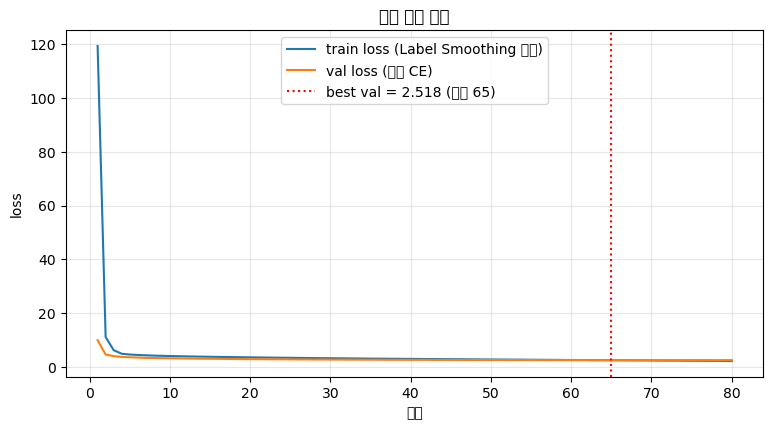

In [25]:
# loss 곡선 — train은 스무딩 눈금이라 val(순수 CE)과 직접 비교하지 말 것
import matplotlib.pyplot as plt

ep = range(1, len(history["train"]) + 1)
plt.figure(figsize=(9, 4.5))
plt.plot(ep, history["train"], label="train loss (Label Smoothing 눈금)")
plt.plot(ep, history["val"], label="val loss (순수 CE)")
plt.axvline(best_epoch, ls=":", c="red", label=f"best val = {best_val:.3f} (에폭 {best_epoch})")
plt.xlabel("에폭"); plt.ylabel("loss"); plt.legend(); plt.grid(alpha=0.3)
plt.title("최종 학습 곡선")
plt.show()


## 8. 실험 서사 — 이 하이퍼파라미터 셋이 나오기까지 (루브릭 2번의 근거)

"과적합을 피할 수 있는 하이퍼파라미터 셋"을 제시하려면, 먼저 우리 데이터에서 과적합이  
실제로 언제 어떻게 시작되는지 눈으로 봐야 한다고 생각했다. 그래서 노트북과 같은 코드를    
스크립트로 만들어 로컬 GPU에서 세 번 실험했다. 사전은 train의 mecab 형태소로만 만들었고  
(val 단어를 사전에 넣는 것도 미세한 누수라서), 매 에폭 val loss와 함께 예문 4개의    
생성 결과를 같이 찍었다 — 5절에서 본 대로 loss만 믿으면 안 되니까.  

공통 설정: mecab 형태소 사전 7,836단어, batch 64, dropout 0.2, 임베딩/출력층 공유,  
Noam warmup 1000, Adam(0.9, 0.98, 1e-9). 시간은 스텝당 53ms(작은 모델)~120ms(큰 모델)로  
에폭당 439스텝이니 23~52초다. 실험 한 사이클이 분 단위다. 덕분에 부담 없이 여러 번 돌릴 수 있었다.  

| 실험 | 모델 | 에폭 | train loss | val loss | 생성 (예문 4개) |
|---|---|---|---|---|---|
| 1 | 1층, d_model 368 (6.0M) | 10 | 3.40 | 3.37 | 전부 "저 도 좋 은 사람 이 에요 ." |
| 2 | 같은 모델 | 40 | 2.51 | 2.95 (계속 하강 중) | 질문별로 갈라지기 시작 |
| 3 | 2층, d_model 512 (18.7M) | 60 | 1.47 | 2.71 (43에폭쯤부터 정체) | 다양해짐, 맥락 맞는 답 등장 |

### 실험 1-2에서 배운 것: 만능 답변은 과소적합의 지문이었다

10에폭 모델은 무슨 질문을 해도 "저 도 좋 은 사람 이 에요 ."만 뱉었다. 처음엔 뭔가    
망가진 줄 알았는데, loss를 보면 train 3.40 / val 3.37로 격차가 거의 없다 — 과적합도  
누수도 아니다(누수의 지문은 "loss는 0 근처인데 생성물이 쓰레기"). 이건 아직 덜 배운    
모델이 greedy 디코딩에서 데이터에 제일 흔한 무난한 답변으로 도망가는 과소적합 증상이다.    
ChatbotData가 연애상담류라 "좋은 사람" 계열 답변이 수백 개 있어서, 어떤 질문 뒤에서도    
안전한 토큰("저", "좋")이 첫 스텝 확률 1등이 되고, greedy는 매번 거기로 들어간다.    
실제로 40에폭까지 더 돌리니(실험 2) val loss가 계속 내려가면서 25에폭쯤부터    
"3박4일 놀러가고 싶다 -> 좋 은 곳 으로 데려다 줄 거 예요" 처럼 질문별로 답이 갈라졌다.    

### 실험 3에서 잡은 것: 과적합의 시작점

작은 모델은 40에폭에도 과소적합이라 과적합을 관찰할 수 없었다. 그래서 일부러 큰 모델    
(2층, d_model 512, 18.7M — 파라미터 3배)을 60에폭 돌렸다.    

```
에폭 30:  train 2.20   val 2.79   <- 아직 같이 내려간다
에폭 43:  train 1.85   val 2.70   <- val이 여기서 멈춘다
에폭 50:  train 1.68   val 2.72   <- train만 내려간다
에폭 60:  train 1.47   val 2.71   <- 격차 1.24
```

val loss가 43에폭쯤 2.70에서 정체되어 2.69~2.73 사이를 진동하는 동안 train은 1.47까지    
계속 내려갔다. 새 문장에 대한 일반화는 멈췄는데 훈련 데이터 암기는 계속되고 있다는 뜻 —    
이게 과적합의 시작이다. 생성 품질은 확실히 좋아져서 "3박4일 놀러가고 싶다 ->    
저 도 데려가 세요" 같은 맥락 맞는 답이 35에폭부터 안정적으로 나왔다.    

### 관찰 하나 더: 1에폭 loss가 100을 넘는 이유

세 실험 모두 1에폭 평균 loss가 100을 넘겨 시작했다 (이 노트북의 최종 학습도 119.4였다). 어휘 7,836개의 무작위 추측이면    
ln(7836) = 8.97 근처여야 하는데 열 배가 넘는다. 원인은 임베딩의 기본 초기화가 N(0,1)인    
채로 출력층과 weight를 공유해서, 초기 logits의 스케일이 커지는 것이다. Xavier 초기화를    
넣으면 초반이 안정될 텐데, 결론에는 영향이 없어서 일단 기록만 해둔다.    

### 라벨 스무딩 실험 — 품질은 논문대로, perplexity 는 논문과 반대로 나왔다

과적합 시작점(43에폭)을 잡았으니 방어 수단을 하나씩 검증했다. 먼저 4-9절에서 보류했던    
Label Smoothing. 같은 큰 모델에 스무딩 0.1만 켜고 60에폭을 돌렸다 (train loss에만 걸고    
val은 순수 CE — 눈금을 안 바꿔야 비교가 된다).    

| | LS 없음 | LS 0.1 |
|---|---|---|
| best val (순수 CE) | 2.6923 (57에폭) | 2.5754 |
| val 정체 시작 | 43에폭 (2.70) | 55에폭 넘어서도 하강 |
| 생성 | "저도 데려가세요" | "너무 화가 나 -> 제가 있잖아요" (공감형) |

과적합 진입이 43에폭에서 55에폭 이후로 밀렸고 best val도 0.12 좋아졌다. 스무딩을 켠    
쪽의 train loss "숫자"는 더 크게 보이는데, 목표 자체가 원-핫에서 0.9로 바뀌어 눈금이    
달라진 것뿐이다. 그리고 여기서 예상이 하나 깨졌다. 4-9절에 옮겨 적은 논문 얘기는 "스무딩을 켜면 perplexity 는
나빠지고 BLEU 만 올라간다"였는데, 내 실측은 눈금이 같은 val CE 마저 0.12 좋아졌다.
품질만 논문대로였고 perplexity 는 반대로 나온 셈이다. 데이터가 2.8만 쌍뿐이라 규제의 이득이
loss 에까지 남은 것으로 보인다. 논문 사례를 내 데이터의 사례처럼 옮겨 적으면 안 된다는 걸 배웠다.    

### 밤샘 실험 — 방어 카드 전부를 하나씩 꺼보다

여기까지 방어 카드 다섯 장(공유, dropout, 증강, 조기종료, LS)을 "주장"했는데, 실측    
근거가 있는 건 LS뿐이었다. 그래서 카드를 하나씩만 끄는 실험 5개를 밤새 순차로 돌렸다.    

**어떻게 돌렸나.** 이 노트북 7절과 같은 학습 코드를 스크립트로 빼고, 실험 대상만    
명령줄 인자로 제어했다 (한 실험 = 카드 하나만 끄기/바꾸기). 60에폭 하나가 52분이라    
다섯 개를 순차로 밤에 걸어뒀다:    

```
공통: --layers 2 --d_model 512 --d_ff 2048 --epochs 60 --label_smoothing 0.1
[1] --shared_emb 0                          # 임베딩 공유 끄기
[2] --train_file train_orig_tokenized.tsv   # 증강 없이 원본 11,232쌍만
[3] --dropout 0.0                           # dropout 끄기
[4] --seed 43   [5] --seed 44               # 확정 셋의 seed 요동 재기
```

각 인자가 건드리는 코드는 한 줄씩이다: 공유는 `Transformer(..., shared_emb=False)`,
dropout은 생성자 인자, 증강 OFF는 train 파일 교체(split은 동일 seed라 val은 같음),
LS는 `nn.CrossEntropyLoss(reduction="none", label_smoothing=0.1)` 을 train loss에만.

**각 실험의 실제 로그 발췌** (train은 LS 눈금, val은 순수 CE):

```
[1] 임베딩 공유 OFF   val: 10ep 3.215  20ep 2.919  30ep 2.758  40ep 2.668  50ep 2.600  60ep 2.552
[2] 증강 OFF          val: 10ep 3.710  20ep 3.259  30ep 3.049  40ep 2.899  50ep 2.806  60ep 2.723
[3] dropout 0         val: 10ep 3.362  20ep 3.189  24ep 3.179(바닥)  30ep 3.227  40ep 3.282  60ep 3.288
                      train: 60ep 1.619   <- val은 오르는데 train은 곤두박질 = 과적합 U곡선
[4] seed 43           val: 40ep 2.642  59ep 2.537(best)  60ep 2.545
[5] seed 44           val: 40ep 2.680  57ep 2.592(best)  60ep 2.597
```

정리하면, 공통 기준 = 큰 모델 + LS 0.1, best val(순수 CE) 기준:

| 실험 | best val | 몫 |
|---|---|---|
| 확정 셋 seed 42 / 43 / 44 | 2.575 / 2.537 / 2.592 | seed 요동 = 약 ±0.03 |
| dropout 0 | 3.179 (24에폭 뒤 3.29로 상승) | dropout 몫 +0.60 (최대 카드) |
| 증강 OFF (원본 11,232쌍만) | 2.723 | 증강 몫 +0.15 |
| 임베딩 공유 OFF | 2.552 | 공유 몫 = 없음 (아래) |

읽어낸 것:

1. dropout 0은 교과서적 과적합 곡선을 그렸다. val이 24에폭에 3.18로 바닥을 찍고    
   되레 3.29까지 올라가는 동안 train은 1.62로 곤두박질. U자로 꺾여 올라가는 val 곡선을    
   실제로 본 건 처음이다. 방어 카드 중 dropout의 몫이 +0.60으로 압도적이었다.    
2. 증강을 끄면 best val이 2.72로 나빠진다. 증강 2.5배(11,232 -> 28,071)의 몫이 +0.15다.
   다만 이걸 "과적합 방어"의 증거로 읽으면 틀린다. 증강 OFF 곡선은 60에폭까지 계속 내려가는 중이었다
   (3.710 -> 2.723). 과적합은 train 이 내려가는데 val 이 멈추거나 오르는 것인데, 이 실험은 그 구간에
   들어가지도 못했다. 게다가 증강을 끄면 데이터만 주는 게 아니었다 — 에폭당 스텝이 439에서 176으로,
   사전도 7,836에서 6,750단어로 같이 줄었다(로그에 그렇게 찍혀 있다). 즉 "카드 하나만 끈다"는 통제가
   이 실험에서만 깨졌다.
   그래서 정직하게는 +0.15 를 "데이터 양(과 학습량)의 몫"으로 읽어야 하고,
   과적합 방어가 실측으로 잡힌 카드는 dropout 하나뿐이다.    
3. seed 세 개의 요동이 ±0.03이라, LS의 +0.12는 요동의 4배 = 진짜 효과다. 미세한 차이를    
   보고 결정할 땐 이렇게 seed 요동의 크기부터 재봐야 한다.    
4. ★예상이 깨진 것 하나. 임베딩 공유를 끄면 나빠질 줄 알았는데 2.552로 오히려 미세하게    
   좋았다. 다만 그 차이가 seed 요동(±0.03) 안이라, 정직한 결론은 "공유는 val에 중립,    
   대신 파라미터 400만 개를 공짜로 아낀다"다. 노드 본문은 공유가 "성능에 도움이 됩니다"    
   라고 단정하는데, 적어도 이 데이터와 이 스케일에서는 그 주장이 실측으로 지지되지    
   않았다. 반쯤 틀린 주장을 실험이 바로잡아 준 두 번째 사례 (첫 번째는 final_norm의    
   원인). 공유는 파라미터 절약의 이득이 실재하므로 최종 셋에서는 유지한다.    

### 확정: 과적합을 피하는 하이퍼파라미터 셋 (루브릭 2번의 답)

```
모델   : n_layers 2, d_model 512, n_heads 8, d_ff 2048
공유   : shared_emb=True, shared_fc=True  (val 중립 + 파라미터 400만 절약)
방어   : dropout 0.2 (+0.60), 증강 2.5배 (+0.15), Label Smoothing 0.1 (+0.12)   <- 몫은 모두 60에폭 컷 기준
학습   : Noam warmup 1000, Adam(0.9, 0.98, 1e-9), batch 64
종료   : 80에폭 중 val(순수 CE) 기준 best 파라미터 사용 (조기종료)
```

괄호 숫자는 그 카드를 껐을 때 나빠지는 best val의 크기, 즉 각 카드의 실측된 몫이다.


## 9. 챗봇에게 물어보기 — 주어진 예문 4개 (루브릭 3번)

위에서 val 기준 best 시점 파라미터로 되돌린 모델에게, 노드가 지정한 예문 4개와
추가 질문 몇 개를 던진다. 생성은 greedy(매 스텝 최고 확률 토큰)다.


In [26]:
def ask(question):
    # 생문장 -> mecab 형태소 -> greedy 생성 -> 답변
    return greedy_answer(" ".join(mecab.morphs(question)))

official = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간만에 여자친구랑 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]
print("[주어진 예문 4개]")
for q in official:
    print(f"  Q: {q}\n  A: {ask(q)}\n")

print("[추가로 물어본 것들]")
for q in ["심심해", "너무 화가 나", "밥 먹었어?", "내일 시험인데 공부를 하나도 못 했어"]:
    print(f"  Q: {q}  ->  {ask(q)}")


[주어진 예문 4개]
  Q: 지루하다, 놀러가고 싶어.
  A: 저 도 요 !



  Q: 오늘 일찍 일어났더니 피곤하다.
  A: 술 너무 많이 드 시 지 마세요 .

  Q: 간만에 여자친구랑 데이트 하기로 했어.
  A: 마음 이 간단 하 겠 어요 .



  Q: 집에 있는다는 소리야.
  A: 자신 을 우선 순위 로 해 주 세요 .

[추가로 물어본 것들]
  Q: 심심해  ->  지금 도 늦 지 않 았 어요 .


  Q: 너무 화가 나  ->  저 도 좋 아 해요 .
  Q: 밥 먹었어?  ->  맛있 는 거 드세요 .


  Q: 내일 시험인데 공부를 하나도 못 했어  ->  공부 하 고 신청 해 보 세요 .


### 답변에 대한 정직한 평가

이번 실행은 지난 실행들보다 예문 운이 나빴다. "지루하다, 놀러가고 싶어 -> 저도요!"는 짧지만 맥락을 받았고,  
"집에 있는다는 소리야 -> 자신을 우선순위로 해주세요"도 그럴듯하다.  
반면 "피곤하다 -> 술 너무 많이 드시지 마세요"는 피곤의 원인을 술로 넘겨짚었고,  
"데이트 하기로 했어 -> 마음이 간단하겠어요"는 어색하다. 추가 질문에서는  
"밥 먹었어? -> 맛있는 거 드세요"(노드가 예시로 실은 참고 답변과 같은 수준),  
"심심해 -> 지금도 늦지 않았어요"(어긋남)처럼 절반쯤 갈렸다.  

정직하게 기록해 둘 것 두 가지.  

- 같은 코드와 시드로도 실행할 때마다 답과 점수가 조금씩 다르다(GPU 연산 순서의 비결정성).  
  이번 실행의 best val은 2.5183(65에폭)으로 8절 seed 밴드(2.54~2.59)보다 좋은데, 이건 비결정성만의 몫이 아니다
  — 8절 실험들은 60에폭 컷이었고 이번 학습은 80에폭이라 best 를 찾을 구간이 더 길었다
  (이번 실행도 60에폭 시점 val 은 2.5533으로 밴드 언저리다). 그렇게 더 좋은 loss 를 얻고도,  
  예문 답변은 이전 실행("피곤하다 -> 충전하는 시간 그 자체로 소중합니다")보다  
  오히려 못하다. loss가 좋다고 생성이 좋은 게 아니라는 걸 run 간 비교로 또 확인했다.  
- 좋은 결과만 골라 실은 게 아니라, 위 학습 셀의 출력이 이 답변을 만든 그 실행 그대로다.  
  노트북을 다시 돌리면 이 답변들은 달라질 수 있다.  

과정에서 확인한 것: 학습 초반(과소적합)에는 무슨 질문에도 같은 답 하나로 수렴하다가,  
학습이 진행되며 질문별로 답이 갈라졌다. loss 곡선만으로는 절대 안 보이는 변화라서,    
매 에폭 생성을 찍는 습관이 이번에 제값을 했다.    

남은 개선 여지는 디코딩이다. greedy는 매 스텝 1등 토큰만 잡아서 무난한 답으로 도망가는    
경향이 남아 있다. Beam Search(상위 k개 경로 유지)나 샘플링을 붙이는 것이 다음 과제다.   


### 수치로도 재보기 — BLEU (참고치)

예문 눈평가는 아무래도 주관적이라, NLP01 번역기에서 배운 BLEU 를 val 591쌍 전체에 재봤다.  
greedy 로 답변을 만들고 정답 답변과의 n-gram 겹침(corpus BLEU, 짧은 문장의 0점 방지를 위해 smoothing)을 잰다.  

미리 적어두는 주의: 챗봇에서 BLEU 는 태생적으로 박한 지표다. 번역은 정답과 어휘가  
크게 겹치지만, 대화는 같은 질문에 "저랑 놀아요"도 "심심하시겠어요"도 다 맞는 답인데    
참조 답변은 그중 하나뿐이라서, 좋은 답을 내도 겹침이 낮게 나온다. 그래서 이 숫자는    
모델끼리 비교하는 참고치로만 쓰고, 품질 판단은 9절의 생성 사례를 우선한다.    


In [27]:
# val 전체(591쌍)에 greedy 답변을 만들어 corpus BLEU 를 잰다
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

refs, hyps = [], []
for q, a in val_all:
    refs.append([a.split()])                 # 참조 = 정답 답변 (형태소 토큰)
    hyps.append(greedy_answer(q).split())    # 가설 = 모델 답변

bleu = corpus_bleu(refs, hyps, smoothing_function=SmoothingFunction().method1)
print(f"val {len(val_all)}쌍 corpus BLEU: {bleu*100:.2f}")


val 591쌍 corpus BLEU: 4.13


val 591쌍에서 corpus BLEU 4.13이 나왔다. 예상대로 박하다. 번역 과제라면 이 정도 데이터에서도 두 자릿수가 흔한데,
(★이 "두 자릿수" 예상은 나중에 틀린 것으로 드러난다 — NLP03 번역기에서 직접 재보니 2.26 이었고, 그때 이 예상의 근거를 못 댔다. NLP03 7절 참고.)  
챗봇은 좋은 답을 해도 참조 답변과 어휘가 겹칠 이유가 없어서 n-gram 겹침이 바닥에 깔린다.  
그래서 이 숫자는 "챗봇이 나쁘다"가 아니라 "BLEU가 대화를 잴 수 없다"로 읽는 게 맞고, 같은 조건의 모델끼리 비교하는 참고치로만 쓴다.  
(다음 프로젝트인 번역기에서는 같은 지표가 훨씬 유의미해진다 — 정답과 겹쳐야 하는 과제니까.)


## 10. 회고

- 이번 프로젝트에서 제일 크게 배운 것은 "믿지 말고 재보기"였다. 퍼실님의 final_norm 설명(residual 누적)을 재봤더니  
  진범이 달랐고(임베딩의 sqrt(d_model)), 노드 본문의 "임베딩 공유가 성능에 도움" 주장도 재봤더니 val 기준으로는 중립이었다.  
  결론이 맞아도 원인이 다를 수 있고, 그 차이는 실험 설계를 통째로 바꾼다.  
- "돌아간다"와 "맞다"는 다르다. 마스크 규약을 섞으면 에러 없이 정반대로 동작하고, causal mask가 뚫려도 loss는 예쁘게 떨어진다.  
  그래서 누수 테스트(미래 토큰만 바꿔 과거 예측 불변 확인)와 매 에폭 생성 확인을 학습 파이프라인에 박아뒀다.  
- loss 숫자와 품질은 다른 물건이다. 만능 답변(과소적합)일 때 train/val 격차는 오히려 없었고,  
  라벨 스무딩은 train loss "숫자"를 키우면서 품질을 올렸다.  
- 실험은 카드를 하나씩만 꺼서 몫을 재야 한다. dropout +0.60, 증강 +0.15, LS +0.12, 공유 0  
  — 다섯 장을 한꺼번에 켜고 "다 도움이 된다"고 썼다면 절반은 거짓이 될 뻔했다.    
- 아쉬운 것: greedy 디코딩의 무난한 답 선호, 증강의 의미 오염(반의어 치환)은 이번 범위에서 못 고쳤다.  
  각각 Beam Search/샘플링, 문맥 기반 치환(BERT MLM)이 다음 열쇠다.    
